# Exploratory Data Analysis

## Imports

In [52]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Read data

In [53]:
train_data = (
    pd.read_csv(Path("artifacts/raw/train.csv"))
    .sort_values(by=["time", "row", "col"])
    .reset_index(drop=True)
)
train_data.head()

,time,row,col,demand
0,0,0,0,0
1,0,0,1,0
2,0,0,2,5
3,0,0,7,33
4,0,1,3,19


## Data Analysis

In [54]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26930 entries, 0 to 26929
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   time    26930 non-null  int64
 1   row     26930 non-null  int64
 2   col     26930 non-null  int64
 3   demand  26930 non-null  int64
dtypes: int64(4)
memory usage: 841.7 KB


In [55]:
train_data["time"].describe()

count    26930.000000
mean       365.484181
std        211.137843
min          0.000000
25%        183.000000
50%        366.000000
75%        547.000000
max        731.000000
Name: time, dtype: float64

In [56]:
train_data["hour_of_day"] = train_data["time"] % 24
train_data["day"] = train_data["time"] // 24
train_data.tail(10)

,time,row,col,demand,hour_of_day,day
26920,731,5,5,368,11,30
26921,731,5,7,236,11,30
26922,731,6,1,0,11,30
26923,731,6,2,0,11,30
26924,731,6,6,177,11,30
26925,731,7,0,0,11,30
26926,731,7,1,0,11,30
26927,731,7,4,59,11,30
26928,731,7,6,73,11,30
26929,731,7,7,14,11,30


## Charts

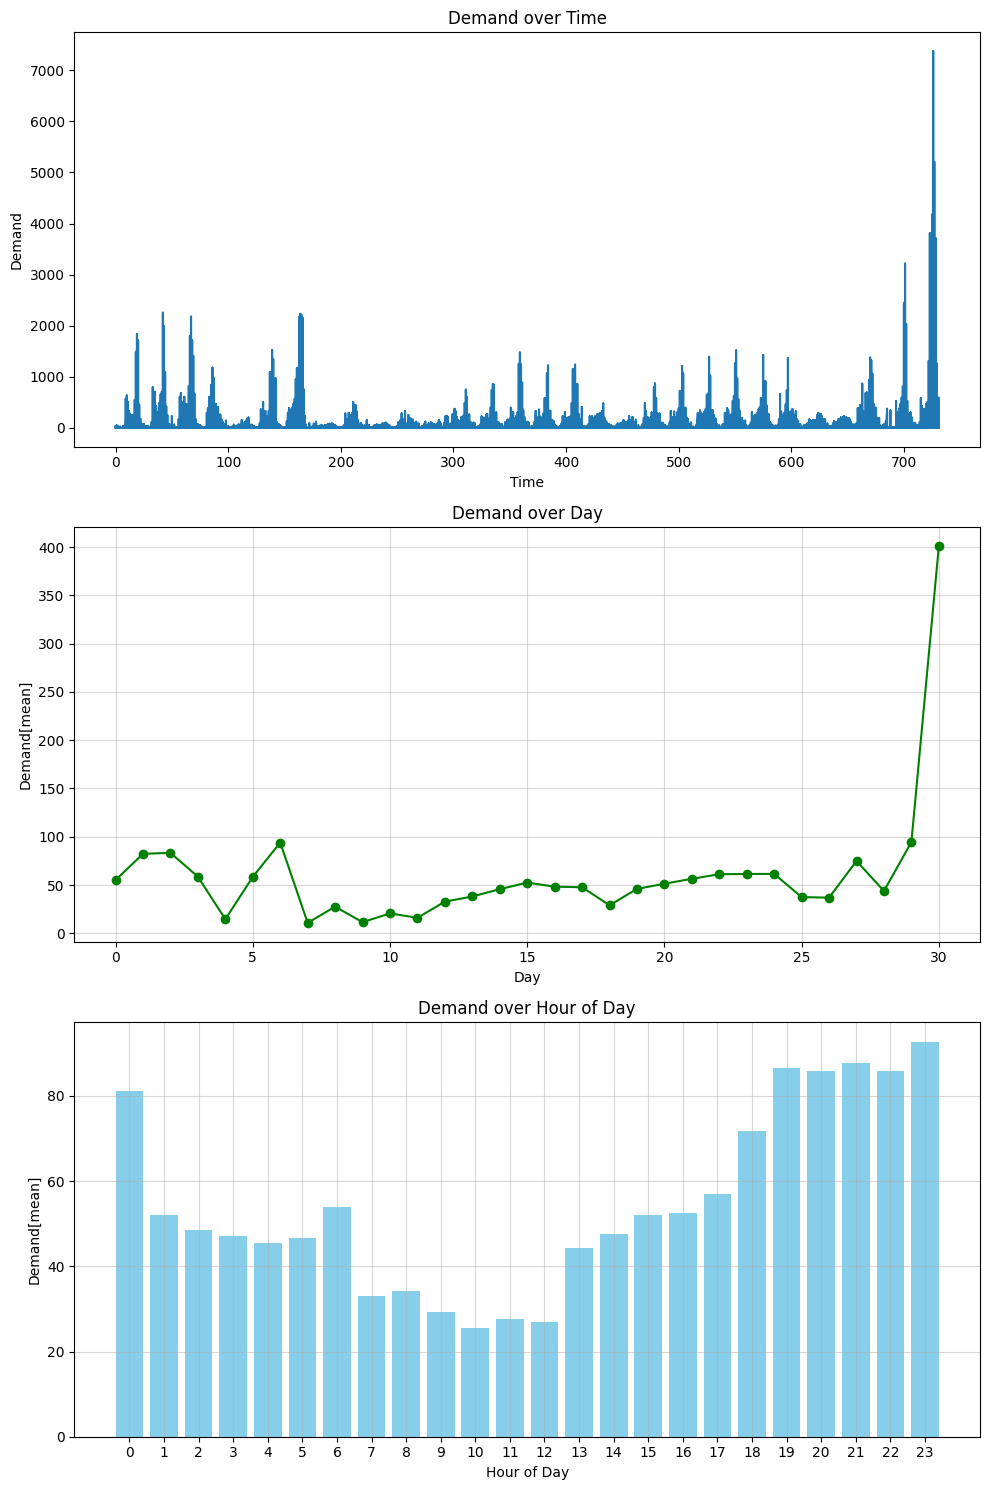

In [57]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))

ax1.plot(train_data["time"], train_data["demand"])
ax1.set_title("Demand over Time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Demand")

# daily demand
daily_demand = train_data.groupby("day")["demand"].mean()
ax2.plot(daily_demand.index, daily_demand.values, "g-", marker="o")
ax2.set_title("Demand over Day")
ax2.set_xlabel("Day")
ax2.set_ylabel("Demand[mean]")
ax2.grid(True, alpha=0.5)

# hourly demand
hourly_demand = train_data.groupby("hour_of_day")["demand"].mean()
ax3.bar(hourly_demand.index, hourly_demand.values, color="skyblue")
ax3.set_title("Demand over Hour of Day")
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Demand[mean]")
ax3.set_xticks(hourly_demand.index)
ax3.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

## Find correct value to shift all times

In [58]:
shifts = range(24)
best_shift = 0
max_variance = float("-inf")

sorted_df = train_data.sort_values("time").reset_index(drop=True)

for shift in shifts:
    ds_temp = sorted_df.copy()
    ds_temp["hour_of_day"] = (ds_temp["time"] + shift) % 24
    # [FACT] 16 - 18 o'clock is the peak time of taxi demands.
    peak_demand = ds_temp[ds_temp["hour_of_day"].isin(range(16, 18))]["demand"].sum()
    # [FACT] 3,4 o'clock is the off-peak time of taxi demands.
    off_peak_demand = ds_temp[ds_temp["hour_of_day"].isin([3, 4])]["demand"].sum()
    variance = peak_demand - off_peak_demand

    if variance > max_variance:
        max_variance = variance
        best_shift = shift

print(
    f"Correct shift value for shifting time to get actual daytime value >> {best_shift}"
)

Correct shift value for shifting time to get actual daytime value >> 17


## Correct data_frame

In [59]:
sorted_df["hour_of_day"] = (sorted_df["time"] + best_shift) % 24
sorted_df["day"] = (sorted_df["time"] + best_shift) // 24

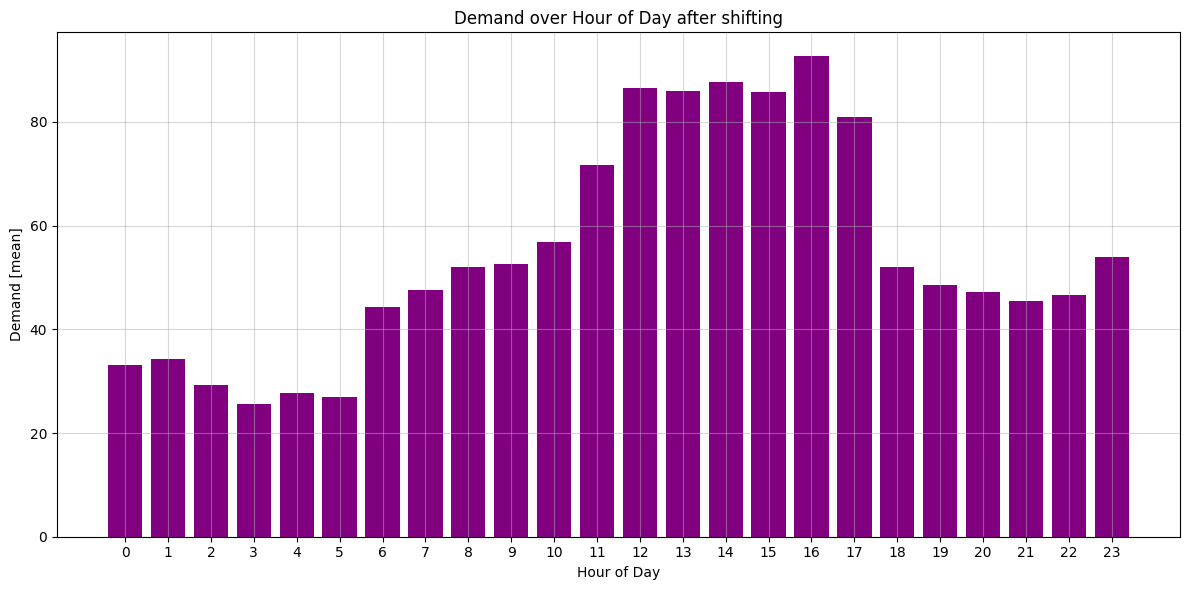

In [60]:
fig, ax = plt.subplots(figsize=(12, 6))
hourly_demand = sorted_df.groupby("hour_of_day")["demand"].mean()
ax.bar(hourly_demand.index, hourly_demand.values, color="purple")
ax.set_title("Demand over Hour of Day after shifting")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Demand [mean]")
ax.set_xticks(hourly_demand.index)
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()